In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
from sklearn.decomposition import PCA
from tqdm import tqdm
import time
import seaborn as sns

In [4]:
def load_and_preprocess(normalize=True, flatten=True, train_sample=None, test_sample=2000, binarize_for_hamming=False):
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    y_train = y_train.flatten()
    y_test = y_test.flatten()

    if train_sample is not None and train_sample < len(x_train):
        idx = np.random.choice(len(x_train), train_sample, replace=False)
        x_train = x_train[idx]
        y_train = y_train[idx]

    if test_sample is not None and test_sample < len(x_test):
        idx = np.random.choice(len(x_test), test_sample, replace=False)
        x_test = x_test[idx]
        y_test = y_test[idx]

    # Normalize
    if normalize:
        x_train = x_train.astype(np.float32) / 255.0
        x_test = x_test.astype(np.float32) / 255.0

    # Optionally binarize for Hamming
    if binarize_for_hamming:
        # global threshold 0.5
        x_train_bin = (x_train > 0.5).astype(int)
        x_test_bin = (x_test > 0.5).astype(int)
        if flatten:
            x_train_bin = x_train_bin.reshape(len(x_train_bin), -1)
            x_test_bin = x_test_bin.reshape(len(x_test_bin), -1)
        return x_train_bin, y_train, x_test_bin, y_test

    if flatten:
        x_train = x_train.reshape(len(x_train), -1)
        x_test = x_test.reshape(len(x_test), -1)

    return x_train, y_train, x_test, y_test

In [5]:
def pairwise_distances(A, B, metric='euclidean', p=3):
    """
    Compute pairwise distances between rows of A (n x d) and B (m x d).
    Returns (n, m) matrix where entry (i,j) is distance between A[i] and B[j].
    Metrics supported: 'euclidean', 'manhattan', 'minkowski', 'cosine', 'hamming'
    """
    if metric == 'euclidean':
        # (a-b)^2 = a^2 + b^2 - 2ab
        A_sq = np.sum(A**2, axis=1).reshape(-1, 1)
        B_sq = np.sum(B**2, axis=1).reshape(1, -1)
        cross = A.dot(B.T)
        dists_sq = A_sq + B_sq - 2*cross
        dists_sq = np.maximum(dists_sq, 0)
        return np.sqrt(dists_sq)
    elif metric == 'manhattan':
        # use broadcasting in chunks to save memory
        # we'll implement outside in predict function to allow chunking
        return np.sum(np.abs(A[:, None, :] - B[None, :, :]), axis=2)
    elif metric == 'minkowski':
        return np.sum(np.abs(A[:, None, :] - B[None, :, :])**p, axis=2)**(1.0/p)
    elif metric == 'cosine':
        # cosine distance = 1 - cosine similarity
        A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
        B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
        sim = A_norm.dot(B_norm.T)
        return 1 - sim
    elif metric == 'hamming':
        # expects binary arrays {0,1}
        return np.mean(A[:, None, :] != B[None, :, :], axis=2)
    else:
        raise ValueError('Unknown metric')

In [6]:
def knn_predict(X_train, y_train, X_test, k=5, metric='euclidean', p=3, chunk_size=200):
    n_test = X_test.shape[0]
    y_pred = np.empty(n_test, dtype=int)

    for start in range(0, n_test, chunk_size):
        end = min(start+chunk_size, n_test)
        X_chunk = X_test[start:end]
        if metric in ['manhattan', 'minkowski', 'hamming']:
            # compute chunk-wise distances using broadcasting but careful with memory
            dists = pairwise_distances(X_chunk, X_train, metric=metric, p=p)
        else:
            dists = pairwise_distances(X_chunk, X_train, metric=metric, p=p)

        # for each test point, select k nearest
        idx_sorted = np.argsort(dists, axis=1)[:, :k]
        neighbors = y_train[idx_sorted]
        # majority vote
        # for ties, choose smallest label
        for i in range(neighbors.shape[0]):
            vals, counts = np.unique(neighbors[i], return_counts=True)
            # pick label with max count, break ties by smallest label
            max_count = np.max(counts)
            candidates = vals[counts == max_count]
            y_pred[start + i] = np.min(candidates)

    return y_pred

In [7]:
def run_experiments(X_train, y_train, X_test, y_test, ks=[1,3,5,7,9], metrics=['euclidean','manhattan','minkowski','cosine','hamming'], p_for_minkowski=3, sample_for_hamming=False, pca_components=None):
    results = {}

    # Optionally reduce dimensionality
    pca = None
    if pca_components is not None:
        print(f"Applying PCA to reduce dims to {pca_components}...")
        pca = PCA(n_components=pca_components)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)

    for metric in metrics:
        print('\n=== Metric:', metric, '===')
        accs = []
        for k in ks:
            print(f"Running K={k}...", end=' ')
            # for hamming, ensure binary
            if metric == 'hamming' and sample_for_hamming:
                X_train_h = (X_train > 0.5).astype(int)
                X_test_h = (X_test > 0.5).astype(int)
                y_pred = knn_predict(X_train_h, y_train, X_test_h, k=k, metric='hamming', chunk_size=200)
            else:
                y_pred = knn_predict(X_train, y_train, X_test, k=k, metric=metric, p=p_for_minkowski, chunk_size=200)
            acc = accuracy_score(y_test, y_pred)
            accs.append(acc)
            print(f"Accuracy: {acc:.4f}")
        results[metric] = accs
    return results, ks

In [8]:
def plot_results(results, ks):
    plt.figure(figsize=(10,6))
    for metric, accs in results.items():
        plt.plot(ks, accs, marker='o', label=metric)
    plt.xlabel('K (number of neighbors)')
    plt.ylabel('Accuracy')
    plt.title('K vs Accuracy for different distance metrics')
    plt.grid(True)
    plt.legend()
    plt.show()


In [9]:
def evaluate_and_report(y_true, y_pred, class_names=None):
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print('\nClassification report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    return cm, acc, precision, recall

In [10]:
def show_samples(X_orig, y_true, y_pred, class_names, n=12):
    # X_orig should have shape (n_samples, 32,32,3) or flattened -> reshape
    if X_orig.ndim == 2:
        X = X_orig.reshape(-1,32,32,3)
    else:
        X = X_orig
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(idxs):
        plt.subplot(3,4,i+1)
        plt.imshow((X[idx]*255).astype(np.uint8))
        plt.axis('off')
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.tight_layout()
    plt.show()

Loading and preprocessing data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Running experiments (this may take time) ...
Applying PCA to reduce dims to 200...

=== Metric: euclidean ===
Running K=1... Accuracy: 0.2785
Running K=3... Accuracy: 0.2750
Running K=5... Accuracy: 0.2930
Running K=7... Accuracy: 0.2880
Running K=9... Accuracy: 0.2920

=== Metric: manhattan ===
Running K=1... Accuracy: 0.2610
Running K=3... Accuracy: 0.2355
Running K=5... Accuracy: 0.2440
Running K=7... Accuracy: 0.2485
Running K=9... Accuracy: 0.2365

=== Metric: minkowski ===
Running K=1... Accuracy: 0.2830
Running K=3... Accuracy: 0.2945
Running K=5... Accuracy: 0.3010
Running K=7... Accuracy: 0.3085
Running K=9... Accuracy: 0.3035

=== Metric: cosine ===
Running K=1... Accuracy: 0.3280
Running K=3... Accuracy: 0.3290
Running K=5... Accuracy: 0.3515
Running K=7... Accuracy: 0.3640
Running K=9... Accuracy: 0.3685

=== Metric: hamming ===
Running K=1... Accuracy: 0.0945
Running K=3... Accuracy: 0.

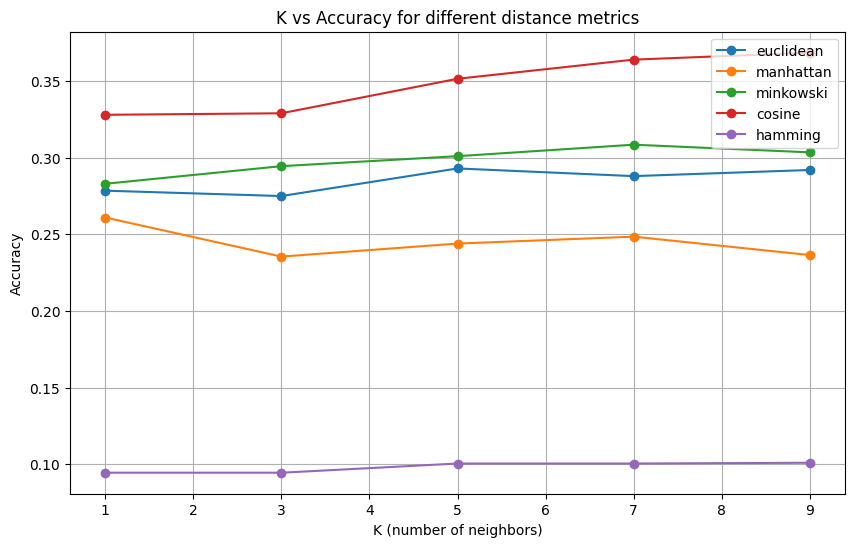

Best result -> Metric: cosine, K: 9, Accuracy: 0.3685
Accuracy: 0.3000
Precision (macro): 0.3774
Recall (macro): 0.2974

Classification report:

              precision    recall  f1-score   support

    airplane       0.36      0.57      0.44       210
  automobile       0.47      0.14      0.21       188
        bird       0.20      0.47      0.28       204
         cat       0.27      0.16      0.20       196
        deer       0.29      0.33      0.31       197
         dog       0.30      0.19      0.23       219
        frog       0.25      0.19      0.22       178
       horse       0.71      0.12      0.21       200
        ship       0.32      0.68      0.44       201
       truck       0.62      0.13      0.21       207

    accuracy                           0.30      2000
   macro avg       0.38      0.30      0.27      2000
weighted avg       0.38      0.30      0.28      2000



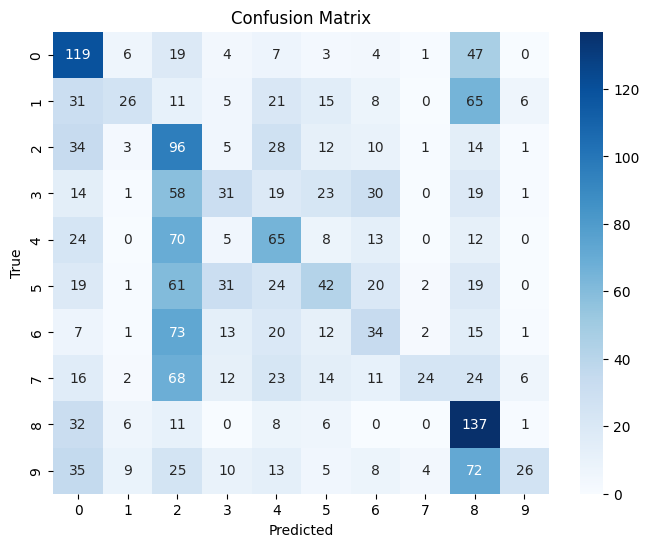

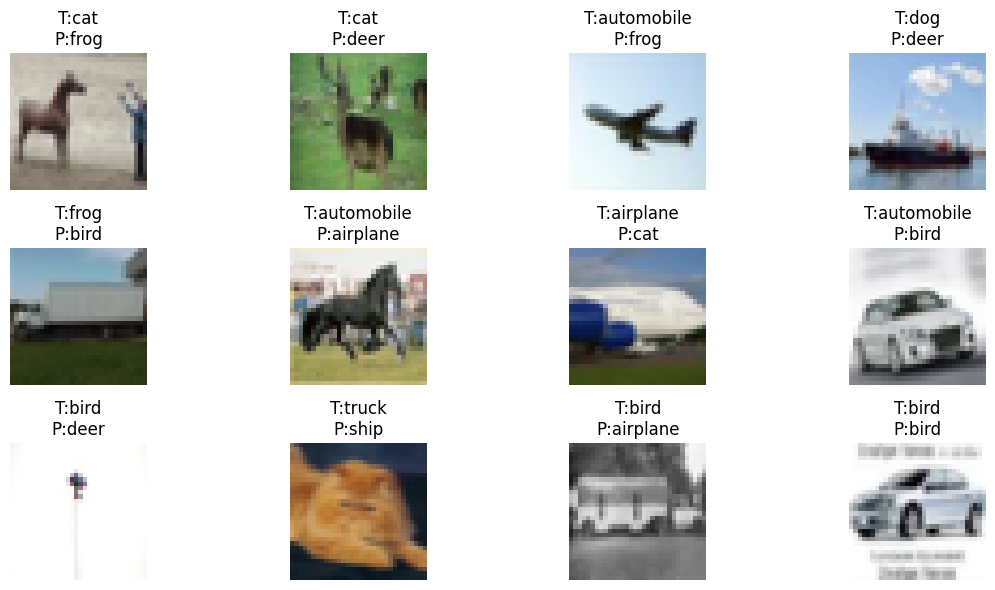

Saved plot to knn_cifar10_results.png


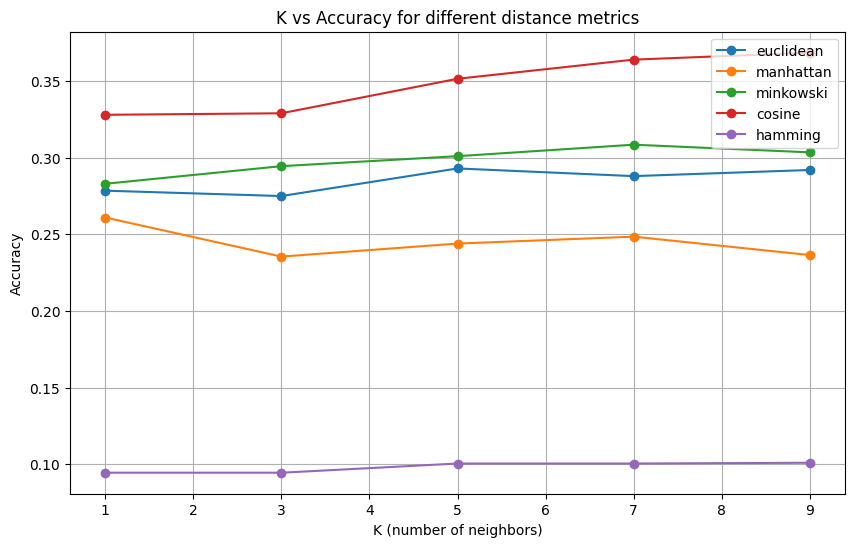

In [11]:
if __name__ == '__main__':
    # Settings - adjust these to manage runtime on your machine
    TRAIN_SAMPLE = 5000   # set to None to use full 50000 (may be very slow)
    TEST_SAMPLE = 2000    # set to 10000 for full test set
    KS = [1,3,5,7,9]
    METRICS = ['euclidean','manhattan','minkowski','cosine','hamming']
    PCA_COMPONENTS = 200  # set to None to not apply PCA; PCA speeds up KNN dramatically
    P_FOR_MINKOWSKI = 3

    class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

    print('Loading and preprocessing data...')
    X_train, y_train, X_test, y_test = load_and_preprocess(normalize=True, flatten=True, train_sample=TRAIN_SAMPLE, test_sample=TEST_SAMPLE, binarize_for_hamming=False)

    # Keep a copy of original images for visualization
    # reload raw images for visualization later
    (_, _), (x_test_raw, _) = cifar10.load_data()
    # if we subsampled test set we need corresponding raw images
    if TEST_SAMPLE is not None and TEST_SAMPLE < len(x_test_raw):
        # pick the same random idx used earlier -> for reproducibility we could set seed; but here we simply sample new ones for display
        idx_display = np.random.choice(len(x_test_raw), TEST_SAMPLE, replace=False)
        x_test_raw = x_test_raw[idx_display]
    x_test_raw = x_test_raw.astype(np.float32) / 255.0

    print('Running experiments (this may take time) ...')
    start_time = time.time()
    results, ks = run_experiments(X_train, y_train, X_test, y_test, ks=KS, metrics=METRICS, p_for_minkowski=P_FOR_MINKOWSKI, sample_for_hamming=False, pca_components=PCA_COMPONENTS)
    end_time = time.time()
    print(f"Experiments finished in {end_time - start_time:.2f} seconds")

    # Plot results
    plot_results(results, ks)

    # Choose best metric and k by highest accuracy
    best_metric = None
    best_k = None
    best_acc = -1
    for metric, accs in results.items():
        for k, acc in zip(ks, accs):
            if acc > best_acc:
                best_acc = acc
                best_metric = metric
                best_k = k
    print(f"Best result -> Metric: {best_metric}, K: {best_k}, Accuracy: {best_acc:.4f}")

    # Recompute predictions for best setting to get confusion matrix etc.
    if best_metric == 'hamming':
        X_train_h = (X_train > 0.5).astype(int)
        X_test_h = (X_test > 0.5).astype(int)
        y_pred_best = knn_predict(X_train_h, y_train, X_test_h, k=best_k, metric='hamming')
    else:
        y_pred_best = knn_predict(X_train, y_train, X_test, k=best_k, metric=best_metric, p=P_FOR_MINKOWSKI)

    cm, acc, prec, rec = evaluate_and_report(y_test, y_pred_best, class_names)

    # Show some sample predictions using raw images
    try:
        show_samples(x_test_raw, y_test, y_pred_best, class_names, n=12)
    except Exception as e:
        print('Could not show raw images:', e)

    # Save the plotted results to disk
    plt.figure(figsize=(10,6))
    for metric, accs in results.items():
        plt.plot(ks, accs, marker='o', label=metric)
    plt.xlabel('K (number of neighbors)')
    plt.ylabel('Accuracy')
    plt.title('K vs Accuracy for different distance metrics')
    plt.grid(True)
    plt.legend()
    plt.savefig('knn_cifar10_results.png', dpi=200)
    print('Saved plot to knn_cifar10_results.png')

